# Data Preprocessing
* Lowercasing
* Tokenization
* Punctuation removal
* Stop word removal
* Lemmatization
--> Save prerpocessed data as pickle

## Install & Import

In [18]:
import kagglehub

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import re
import unicodedata
import spacy
from langdetect import detect

## Load & Inspect

In [19]:
# Download latest version of the data set
path = kagglehub.dataset_download("sumitm004/reddit-raskscience-flair-dataset")
print("Import finished.")

Import finished.


In [20]:
# Load data (relevant columns only)
df = pd.read_csv(f"{path}/flair_data.csv", usecols=[0, 4, 5, 6])
df.head()

,id,question,link_flair_css_class,link_flair_text
0,421zyl,How is time defined at the big bang?,physics,Physics
1,4r857d,UFO best scientific explanation. Atmospherical...,geo,Earth Sciences
2,4r0zwj,It's a commonly known fact that metals oxidize...,chem,Chemistry
3,540ohz,"China builds large telescope, but i have a que...",astro,Astronomy
4,4r191k,Geoscientists: Is there any current research i...,geo,Planetary Sci.


In [ ]:
# Inspect data
print(df.shape)
print()
print(df.columns.tolist())
print()
print(df.info())
print()
print(df.describe())

(612668, 4)

['id', 'question', 'link_flair_css_class', 'link_flair_text']

<class 'pandas.DataFrame'>
RangeIndex: 612668 entries, 0 to 612667
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   id                    612668 non-null  str  
 1   question              612668 non-null  str  
 2   link_flair_css_class  612668 non-null  str  
 3   link_flair_text       612668 non-null  str  
dtypes: str(4)
memory usage: 18.7 MB
None


## Save Raw Data

In [22]:
# Save lemmatized df to pickle file
df.to_pickle("data/raw_data.pkl")

## Clean & Preprocess

### Handling Missing Values

In [23]:
# List the number of missing values per column
df.isnull().sum()

id                      0
question                0
link_flair_css_class    0
link_flair_text         0
dtype: int64

No missing values.


### Handling Duplicates

In [24]:
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

No duplicates.

## Explore & Summarize
The data set contains 612,668 data points corresponding to as many posts in r/askscience. In the following the distribution of papers across time and categories will be examined.

### Colors, Styles & Presets

In [25]:
# Plot style
sns.set_theme(style='whitegrid', context='paper')

### Distribution across Categories

In [26]:
len(df['link_flair_css_class'].unique().tolist())

16

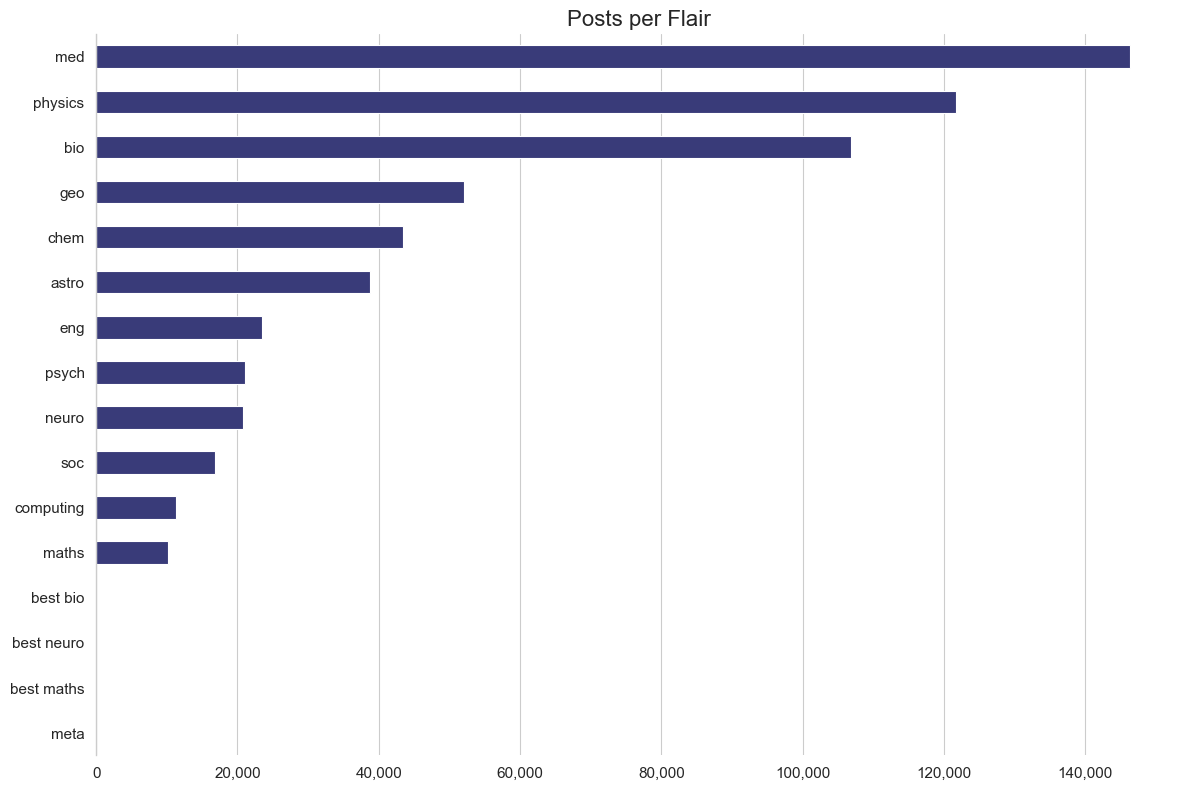

In [27]:
counts = df["link_flair_css_class"].value_counts()
counts = counts.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12,8))
counts.plot(kind="barh", ax=ax, colormap='tab20b')

plt.xlabel("")
plt.ylabel("")
plt.title("Posts per Flair", fontsize=16)
plt.yticks(fontsize=11)
plt.xticks(fontsize=11)

# Format x-axis with commas
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Despine plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Hide horizontal gridlines
plt.grid(axis="y", visible=False)

plt.tight_layout()

plt.savefig('viz/EDA_posts_per_flair.png', dpi=300)
plt.show()

The distribution of posts across css_classes (which seems to correspond to a high level classification of academic disciplines) shows that medicine, physics and biology are by far the most asked sciences. The categories *meta* and *best ...* each contain only one post. It is not fully clear what these classes are, presumably platform artifacts indicating posts with high upvotes or similar.

In [28]:
counts

link_flair_css_class
meta               1
best maths         1
best neuro         1
best bio           2
maths          10162
computing      11277
soc            16804
neuro          20797
psych          21047
eng            23502
astro          38772
chem           43436
geo            52007
bio           106808
physics       121776
med           146275
Name: count, dtype: int64

## Clean & Preprocessing for NLP

In [29]:
df

,id,question,link_flair_css_class,link_flair_text
0,421zyl,How is time defined at the big bang?,physics,Physics
1,4r857d,UFO best scientific explanation. Atmospherical...,geo,Earth Sciences
2,4r0zwj,It's a commonly known fact that metals oxidize...,chem,Chemistry
3,540ohz,"China builds large telescope, but i have a que...",astro,Astronomy
4,4r191k,Geoscientists: Is there any current research i...,geo,Planetary Sci.
...,...,...,...,...
612663,ry6of6,Dentists! I've got a question for you: why do ...,med,Medicine
612664,ry6nvu,Why did we evolve to have consciousness?,bio,Biology
612665,ry6nle,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences
612666,rwkxsm,Would tracing paper be classed as translucent ...,physics,Physics


## Raw Text Cleaning

In [30]:
def basic_clean(text):
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove reddit mentions
    text = re.sub(r"/u/\w+|/r/\w+", "", text)

    # normalize unicode (IMPORTANT for El Niño, naïve, etc.)
    text = unicodedata.normalize("NFKC", text)

    # keep letters + spaces only (still multilingual-safe at this stage)
    text = re.sub(r"[^\w\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_text"] = df["question"].apply(basic_clean)

## Language Detection

In [31]:
def is_english(text):
    try:
        return detect(text) == "en"
    except:
        return False

df = df[df["clean_text"].apply(is_english)].copy()
df

,id,question,link_flair_css_class,link_flair_text,clean_text
0,421zyl,How is time defined at the big bang?,physics,Physics,how is time defined at the big bang
1,4r857d,UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,ufo best scientific explanation atmospherical ...
2,4r0zwj,It's a commonly known fact that metals oxidize...,chem,Chemistry,it s a commonly known fact that metals oxidize...
4,4r191k,Geoscientists: Is there any current research i...,geo,Planetary Sci.,geoscientists is there any current research in...
5,4r18ga,"Why are there so many ""accident"" babies yet so...",bio,Biology,why are there so many accident babies yet so m...
...,...,...,...,...,...
612663,ry6of6,Dentists! I've got a question for you: why do ...,med,Medicine,dentists i ve got a question for you why do de...
612664,ry6nvu,Why did we evolve to have consciousness?,bio,Biology,why did we evolve to have consciousness
612665,ry6nle,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,why don t the oceans get saltier over time or ...
612666,rwkxsm,Would tracing paper be classed as translucent ...,physics,Physics,would tracing paper be classed as translucent ...


## Tokenization & Lemmatization

In [32]:
nlp = spacy.load("en_core_web_sm")

def clean_tokens(text):
    doc = nlp(text)

    tokens = []

    for token in doc:
        lemma = token.lemma_.lower()

        # must be alphabetic
        if not lemma.isalpha():
            continue

        # keep Latin + accented Latin only
        if not re.match(r"^[A-Za-zÀ-ÖØ-öø-ÿ]+$", lemma):
            continue

        if token.is_stop:
            continue

        if len(lemma) < 3:
            continue

        if re.fullmatch(r"(.)\1{2,}", lemma):
            continue

        tokens.append(lemma)

    return tokens

df["tokens"] = df["clean_text"].apply(clean_tokens)

In [33]:
# Remove documents with less than 4 tokens
df = df[df["tokens"].apply(lambda x: len(x) > 3)].copy()

In [34]:
# Convert tokens to string vectorization
df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))
df

,id,question,link_flair_css_class,link_flair_text,clean_text,tokens
0,421zyl,How is time defined at the big bang?,physics,Physics,time define big bang,"[time, define, big, bang]"
1,4r857d,UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,ufo good scientific explanation atmospherical ...,"[ufo, good, scientific, explanation, atmospher..."
2,4r0zwj,It's a commonly known fact that metals oxidize...,chem,Chemistry,commonly know fact metal oxidize possible dize...,"[commonly, know, fact, metal, oxidize, possibl..."
4,4r191k,Geoscientists: Is there any current research i...,geo,Planetary Sci.,geoscientist current research project shortfal...,"[geoscientist, current, research, project, sho..."
5,4r18ga,"Why are there so many ""accident"" babies yet so...",bio,Biology,accident baby people struggle conceive,"[accident, baby, people, struggle, conceive]"
...,...,...,...,...,...,...
612662,ry6rh0,2 doses of vaccines protect against severe ill...,med,COVID-19,dos vaccine protect severe illness infection m...,"[dos, vaccine, protect, severe, illness, infec..."
612663,ry6of6,Dentists! I've got a question for you: why do ...,med,Medicine,dentist get question dentist labeling advise c...,"[dentist, get, question, dentist, labeling, ad..."
612665,ry6nle,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,don ocean salty time,"[don, ocean, salty, time]"
612666,rwkxsm,Would tracing paper be classed as translucent ...,physics,Physics,trace paper class translucent transparent like...,"[trace, paper, class, translucent, transparent..."


## Save Preprocessed Data

In [35]:
# Save lemmatized df to pickle file
df.to_pickle("data/preprocessed_data.pkl")